In [2]:
from itertools import count
from xml.sax.handler import property_interning_dict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import average

In [3]:
data = pd.read_csv("BlinkIT_Grocery_Data_clean.csv")
data

,Item_Fat_Content,Item_Identifier,Item_Type,Outlet_Establishment_Year,Outlet_Identifier,Outlet_Location_Type,Outlet_Size,Outlet_Type,Item_Visibility,Item_Weight,Total_Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.6,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,\N,164.5526,4.0
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,\N,241.6828,4.0
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,\N,86.6198,4.0
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,\N,97.8752,4.0


In [4]:
Total_Sales = data.Total_Sales.sum().round(2)
print('$',Total_Sales)

$ 1201681.48


In [5]:
AVG_Sales = round(np.average(data.Total_Sales),2)
print('$',AVG_Sales)

$ 140.99


In [6]:
No_of_items = np.count_nonzero(data.Item_Identifier)
print(No_of_items)

8523


In [7]:
AVG_Rating = round(np.average(data.Rating),2)
print(AVG_Rating)

3.97


In [8]:
Total_Sales_by_Fat_Content = data.groupby("Item_Fat_Content", as_index=False)["Total_Sales"].sum().round(2).sort_values(by="Total_Sales", ascending=False)
print(Total_Sales_by_Fat_Content)

  Item_Fat_Content  Total_Sales
0          Low Fat    776319.68
1          Regular    425361.80


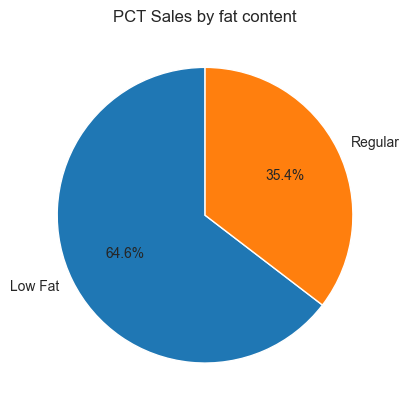

In [9]:
Total_Sales_by_Fat_Content = data.groupby("Item_Fat_Content")["Total_Sales"].sum()
plt.pie(Total_Sales_by_Fat_Content, labels=Total_Sales_by_Fat_Content.index, autopct='%0.1f%%', startangle=90)
plt.title('PCT Sales by fat content')
plt.show()

In [10]:
Total_Sales_by_Item_Type = data.groupby('Item_Type', as_index=False)["Total_Sales"].sum().round(2).sort_values(by="Total_Sales",ascending=False)
print(Total_Sales_by_Item_Type)

                Item_Type  Total_Sales
6   Fruits and Vegetables    178124.08
13            Snack Foods    175433.92
9               Household    135976.53
5            Frozen Foods    118558.88
4                   Dairy    101276.46
3                  Canned     90706.73
0            Baking Goods     81894.74
8      Health and Hygiene     68025.84
10                   Meat     59449.86
14            Soft Drinks     58514.16
1                  Breads     35379.12
7             Hard Drinks     29334.68
11                 Others     22451.89
15          Starchy Foods     21880.03
2               Breakfast     15596.70
12                Seafood      9077.87


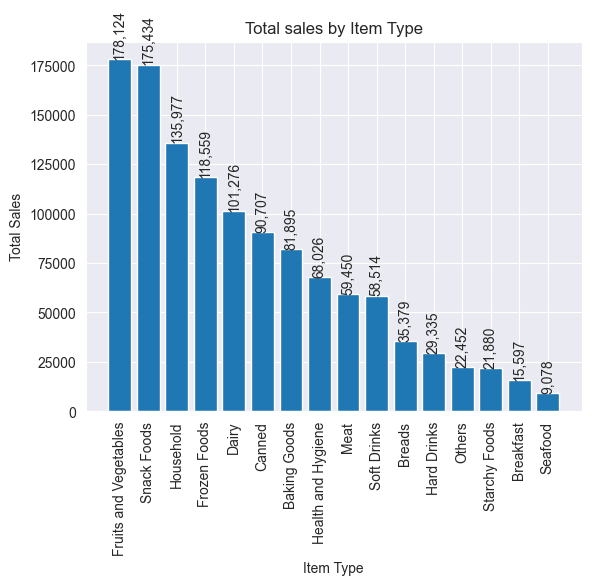

In [11]:
Total_Sales_by_Item_Type = data.groupby('Item_Type')["Total_Sales"].sum().sort_values(ascending=False)
bars = plt.bar(Total_Sales_by_Item_Type.index, Total_Sales_by_Item_Type.values)
plt.title('Total sales by Item Type')
plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, rotation=90)

plt.show()

In [12]:
Fat_Content_by_Outlet_for_Total_sales = data.pivot_table(values="Total_Sales", index="Outlet_Location_Type", columns="Item_Fat_Content", aggfunc="sum", fill_value=0).round(2).sort_index()

print(Fat_Content_by_Outlet_for_Total_sales)


Item_Fat_Content        Low Fat    Regular
Outlet_Location_Type                      
Tier 1                215047.91  121349.90
Tier 2                254464.77  138685.87
Tier 3                306806.99  165326.03


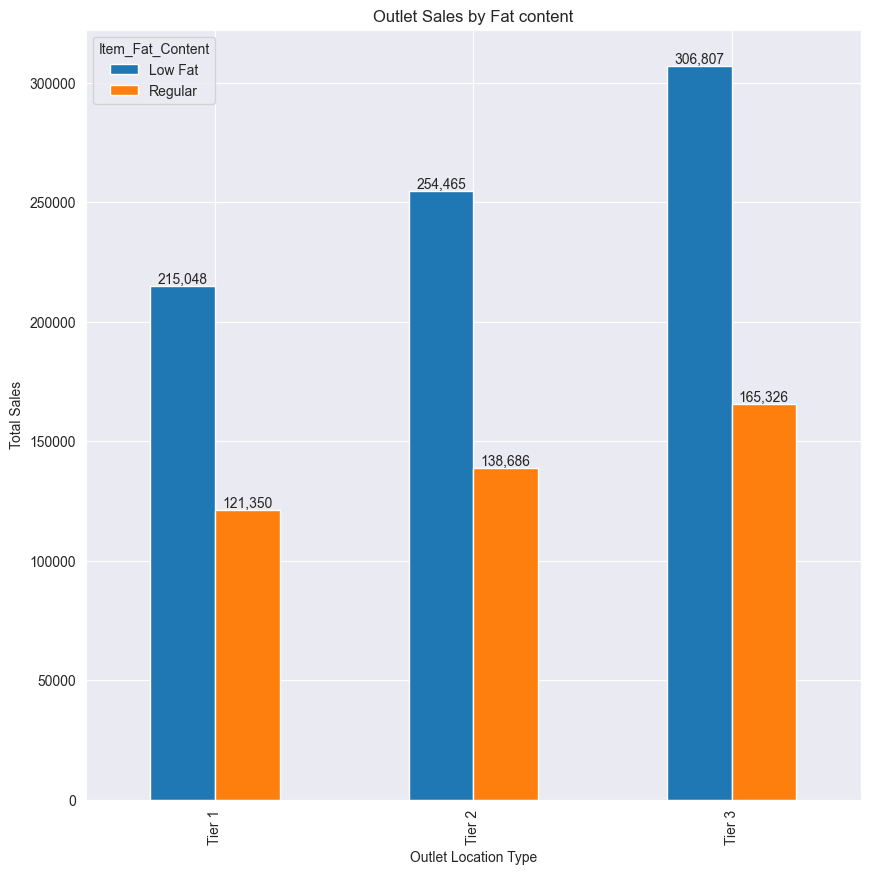

In [13]:
Fat_Content_by_Outlet_for_Total_sales = data.groupby(['Outlet_Location_Type', 'Item_Fat_Content'])['Total_Sales'].sum().unstack()

ax=Fat_Content_by_Outlet_for_Total_sales.plot(kind='bar', figsize=(10,10), title='Outlet Sales by Fat content')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
plt.show()

In [14]:
Total_Sales_by_Outlet_Establishement_Year = data.groupby("Outlet_Establishment_Year", as_index=False)["Total_Sales"].sum().round(2).sort_values(by="Total_Sales", ascending=False)
print(Total_Sales_by_Outlet_Establishement_Year)

   Outlet_Establishment_Year  Total_Sales
0                       1998    204522.26
6                       2017    133103.91
2                       2010    132113.37
1                       2000    131809.02
8                       2022    131477.77
5                       2015    130942.78
4                       2012    130476.86
7                       2020    129103.96
3                       2011     78131.56


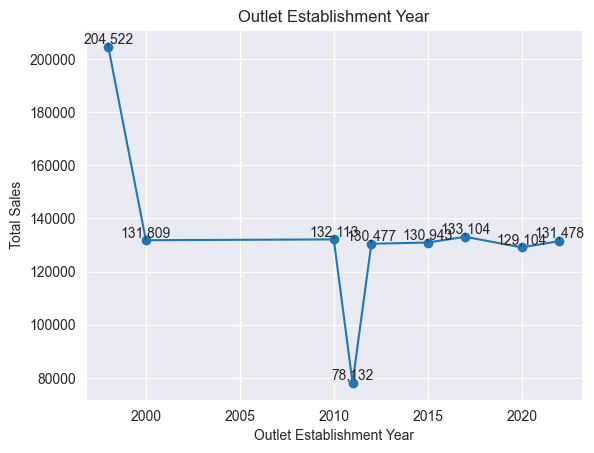

In [15]:
Total_Sales_by_Outlet_Establishement_Year = data.groupby("Outlet_Establishment_Year")["Total_Sales"].sum()
plt.plot(Total_Sales_by_Outlet_Establishement_Year.index, Total_Sales_by_Outlet_Establishement_Year.values, marker='o', linestyle='-', label='Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment Year')
for x,y in zip(Total_Sales_by_Outlet_Establishement_Year.index, Total_Sales_by_Outlet_Establishement_Year.values):
    plt.text(x,y, f'{y:,.0f}', ha='center', va='bottom', fontsize=10)
plt.show()

In [16]:
Total_Sales_by_Outlet_Size = data.groupby("Outlet_Size", as_index=False)["Total_Sales"].sum().round(2).sort_values(by="Total_Sales", ascending=False)
print(Total_Sales_by_Outlet_Size)


  Outlet_Size  Total_Sales
1      Medium    507895.73
2       Small    444794.17
0        High    248991.58


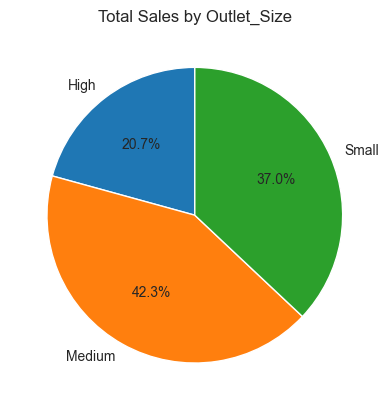

In [21]:
Total_Sales_by_Outlet_Size = data.groupby("Outlet_Size")["Total_Sales"].sum()
plt.pie(Total_Sales_by_Outlet_Size, labels=Total_Sales_by_Outlet_Size.index, autopct='%0.1f%%', startangle=90)
plt.title('Total Sales by Outlet_Size')
plt.show()


In [87]:
Total_Sales_by_Outlet_Size["Percentage"] = (
        (Total_Sales_by_Outlet_Size["Total_Sales"] * 100) / Total_Sales_by_Outlet_Size["Total_Sales"].sum()
).round(2)

print(Total_Sales_by_Outlet_Size)

  Outlet_Size  Total_Sales  Percentage
1      Medium    507895.73       42.27
2       Small    444794.17       37.01
0        High    248991.58       20.72


In [85]:
Total_Sales_by_Outlet_Location = data.groupby("Outlet_Location_Type", as_index=False)["Total_Sales"].sum().round(2).sort_values(by="Total_Sales", ascending=False)
print(Total_Sales_by_Outlet_Location)

  Outlet_Location_Type  Total_Sales
2               Tier 3    472133.03
1               Tier 2    393150.64
0               Tier 1    336397.81


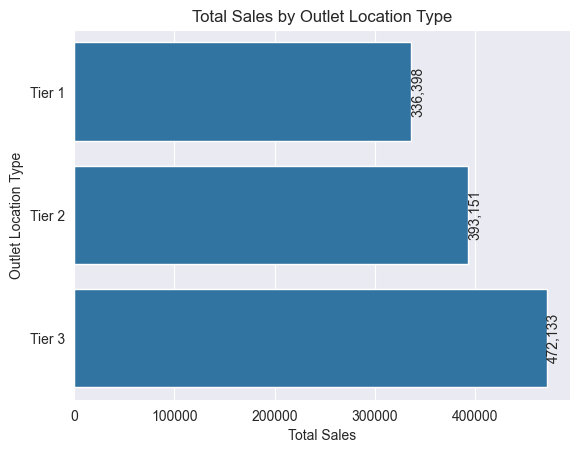

In [35]:
Total_Sales_by_Outlet_Location = data.groupby("Outlet_Location_Type")["Total_Sales"].sum().reset_index()
ax = sns.barplot(x='Total_Sales', y='Outlet_Location_Type', data=Total_Sales_by_Outlet_Location)

plt.ylabel('Outlet Location Type')
plt.xlabel('Total Sales')
plt.title('Total Sales by Outlet Location Type')

for i, v in enumerate(Total_Sales_by_Outlet_Location["Total_Sales"]):
    plt.text(v, i, f'{v:,.0f}', va='center', fontsize=10, rotation=90)
